# Chapter 05 — Swap Risk Sensitivity

# 1. Introduction
## DV01, PV01, Key Rate Risk, and Scenario Analysis

In this chapter we move from:

> pricing

to:

> risk management and trading analytics.

We now study:

- DV01
- PV01
- key rate sensitivities
- curve shocks
- steepener trades
- flattener trades
- scenario analysis


## Why This Chapter Matters

In real trading systems:

> risk is often more important than pricing.

Front-office rates desks continuously monitor:

- portfolio DV01
- curve exposure
- bucketed risk
- hedge ratios
- stress scenarios

This chapter introduces the foundations of:

- rates risk management
- FO trading analytics
- XVA sensitivities
- VaR infrastructure

---

# 2. Import Libraries

In [1]:
import sys
sys.path.append("../python")

import numpy as np
import matplotlib.pyplot as plt

from curve import YieldCurve
from swap import InterestRateSwap

from risk import (
    dv01,
    pv01,
    parallel_shift_curve
)

from key_rate_risk import (
    key_rate_dv01
)

from scenario_analysis import (
    steepener_scenario,
    flattener_scenario
)

from market_data import load_market_curve

plt.rcParams["figure.figsize"] = (10,6)

print("Libraries imported successfully.")

Libraries imported successfully.


---
# 3. What is Risk Sensitivity?

Financial instruments change value when markets move.

Risk sensitivity measures:

> how much instrument value changes
> when market variables change.

## In Rates Trading

The most important market variable is:

\[
\text{Interest Rates}
\]

Rates products are highly sensitive to:

- yield curve shifts
- forward rate changes
- curve steepening
- curve flattening

## Why Traders Care

Rates desks continuously monitor:

- DV01
- PV01
- bucketed risk
- scenario exposure

because:

small curve changes can generate large PnL swings.

---

# 4. Loading Market Curve

We now load a simplified USD zero curve.

In production systems curves are built from:

- OIS swaps
- futures
- IRS instruments
- treasury products

For educational purposes we use simplified data.

In [2]:
maturities, rates = load_market_curve(
    "../data/usd_zero_curve.csv"
)

curve = YieldCurve(
    maturities,
    rates
)

print("Curve loaded successfully.")

Curve loaded successfully.


---
# 5. Market Zero Curve

The zero curve determines:

- discounting
- forwards
- swap valuation
- risk sensitivities

The shape of the curve strongly affects risk exposure.

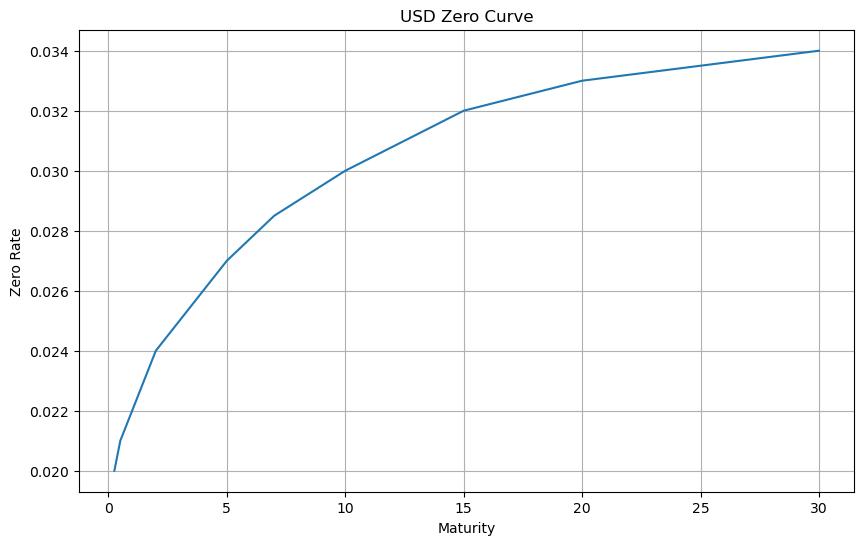

In [3]:
plt.figure()

plt.plot(
    maturities,
    rates
)

plt.title("USD Zero Curve")

plt.xlabel("Maturity")

plt.ylabel("Zero Rate")

plt.grid()

plt.show()

---
# 6. Constructing a Vanilla Payer Swap

We now create:

- 5Y payer swap
- semiannual payments
- fixed rate = 3%
- notional = 10 million

A payer swap:

- pays fixed
- receives floating

Payer swaps benefit when rates rise.


In [4]:
swap = InterestRateSwap(
    notional=10_000_000,
    fixed_rate=0.03,
    maturity=5,
    payment_frequency=2,
    payer=True
)

print("Swap created successfully.")

Swap created successfully.


---
# 7. Base Swap NPV

Before computing risk we first compute:

\[
\text{Base NPV}
\]

This is the current value of the swap.

In [5]:
base_npv = swap.npv(curve)

print(
    f"Base Swap NPV = ${base_npv:,.2f}"
)

Base Swap NPV = $-137,033.04


---
# 8. DV01 Theory

DV01 measures:

> the dollar value change
> for a 1 basis point move in rates.

## Formula

$$
DV01 = PV(r+1bp)-PV(r)
$$

## Interpretation

Large DV01 means:

- high duration exposure
- high interest rate sensitivity

## Why DV01 Matters

DV01 is one of the most important metrics on rates trading desks.

Traders use DV01 for:

- hedging
- risk aggregation
- portfolio balancing
- macro positioning

## PV01

PV01 is simply:

$$
PV01 = |DV01|
$$

It measures:

> absolute risk magnitude.

In [7]:
swap_dv01 = dv01(
    swap,
    curve
)

print(
    f"Swap DV01 = ${swap_dv01:,.2f}"
)

Swap DV01 = $4,744.40


In [6]:
swap_pv01 = pv01(
    swap,
    curve
)

print(
    f"Swap PV01 = ${swap_pv01:,.2f}"
)

Swap PV01 = $4,744.40


---
# 9. Parallel Curve Shifts

We now shift the entire curve upward.

This simulates:

- inflation fears
- central bank tightening
- liquidity stress


Parallel shifts are commonly used for:

- stress testing
- hedge analysis
- VaR systems


## 9.1 Apply Parallel Shift

In [8]:
shifted_curve = parallel_shift_curve(
    curve,
    50
)

## 9.2 Compare Curves

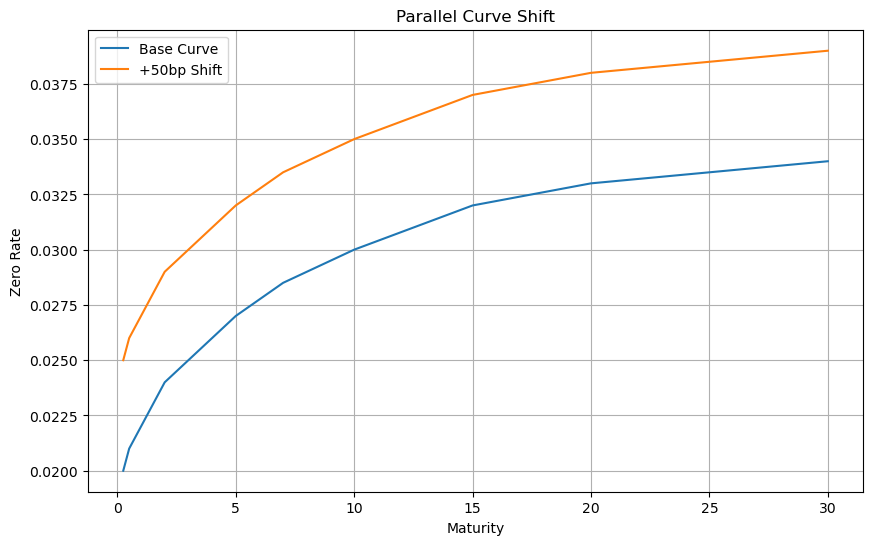

In [9]:
plt.figure()

plt.plot(
    maturities,
    rates,
    label="Base Curve"
)

plt.plot(
    shifted_curve.maturities,
    shifted_curve.zero_rates,
    label="+50bp Shift"
)

plt.title("Parallel Curve Shift")

plt.xlabel("Maturity")

plt.ylabel("Zero Rate")

plt.legend()

plt.grid()

plt.show()


## 9.3 Repricing the Swap under shift

We now compute:

$$
NPV_{shifted}
$$

and compare against the base case.

In [11]:
shifted_npv = swap.npv(
    shifted_curve
)

print(
    f"Base NPV = ${base_npv:,.2f}"
)

print(
    f"Shifted NPV = ${shifted_npv:,.2f}"
)

print(
    f"PnL Change = ${shifted_npv-base_npv:,.2f}"
)

Base NPV = $-137,033.04
Shifted NPV = $97,375.26
PnL Change = $234,408.30


## 9.4 NPV Sensitivity Visualization

We now compute swap value under many curve shifts.

This produces:

$$
NPV(\Delta r)
$$

This graph helps traders visualize:

- directional exposure
- convexity
- hedge effectiveness

In [12]:
shifts = np.linspace(
    -0.02,
    0.02,
    41
)

npvs = []

for s in shifts:

    shocked_curve = YieldCurve(
        maturities,
        rates + s
    )

    npvs.append(
        swap.npv(shocked_curve)
    )


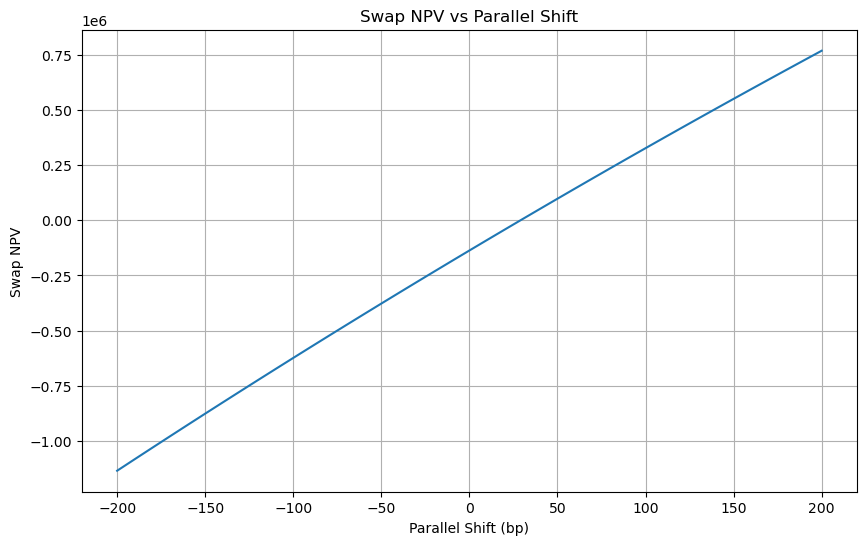

In [13]:
plt.figure()

plt.plot(
    shifts * 10000,
    npvs
)

plt.title(
    "Swap NPV vs Parallel Shift"
)

plt.xlabel(
    "Parallel Shift (bp)"
)

plt.ylabel(
    "Swap NPV"
)

plt.grid()

plt.show()


---
# 10. Key Rate Risk

Parallel shifts are unrealistic.

Real yield curves move differently at different maturities.

Key rate risk measures sensitivity to:

- 2Y point
- 5Y point
- 10Y point
- etc.

## Why Traders Care

Bucketed risk is critical for:

- hedging
- curve trading
- liquidity management

## 10.1 Compute Key Rate DV01

In [14]:
key_maturities = [
    1,
    2,
    5,
    10,
    20,
    30
]

key_risks = []

for m in key_maturities:

    kr = key_rate_dv01(
        swap,
        curve,
        m
    )

    key_risks.append(kr)

    print(
        f"{m}Y Key Rate DV01 = ${kr:,.2f}"
    )


1Y Key Rate DV01 = $25.54
2Y Key Rate DV01 = $57.09
5Y Key Rate DV01 = $4,516.96
10Y Key Rate DV01 = $0.00
20Y Key Rate DV01 = $0.00
30Y Key Rate DV01 = $0.00


## 10.2 Plot Key Rate Risk

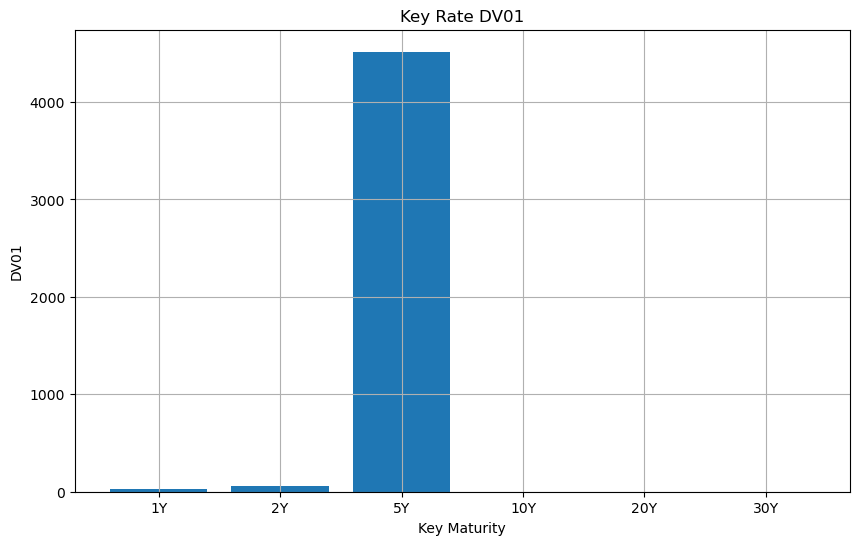

In [15]:
plt.figure()

plt.bar(
    [str(m)+"Y" for m in key_maturities],
    key_risks
)

plt.title(
    "Key Rate DV01"
)

plt.xlabel(
    "Key Maturity"
)

plt.ylabel(
    "DV01"
)

plt.grid()

plt.show()

---
# 11. Scenario Analysis

Real markets rarely move in parallel.

We now build:

- steepener scenarios
- flattener scenarios


## Steepener

Long-end rises more than short-end.

Typical interpretation:

- inflation concerns
- term premium expansion


## Flattener

Short-end rises more than long-end.

Typical interpretation:

- aggressive central bank tightening
- recession fears

## 11.1 Build Scenario Curves

In [16]:
steepener_curve = steepener_scenario(
    curve
)

flattener_curve = flattener_scenario(
    curve
)

## 11.2 Plot Scenario Curves

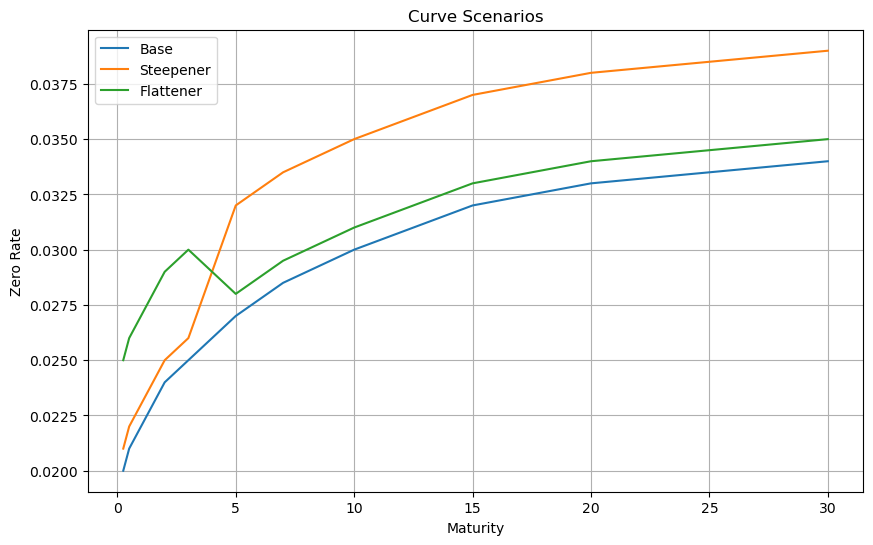

In [17]:
plt.figure()

plt.plot(
    maturities,
    rates,
    label="Base"
)

plt.plot(
    maturities,
    steepener_curve.zero_rates,
    label="Steepener"
)

plt.plot(
    maturities,
    flattener_curve.zero_rates,
    label="Flattener"
)

plt.title(
    "Curve Scenarios"
)

plt.xlabel(
    "Maturity"
)

plt.ylabel(
    "Zero Rate"
)

plt.legend()

plt.grid()

plt.show()

## 11.3 Scenario Repricing

In [18]:
steepener_npv = swap.npv(
    steepener_curve
)

flattener_npv = swap.npv(
    flattener_curve
)

print(
    f"Base NPV = ${base_npv:,.2f}"
)

print(
    f"Steepener NPV = ${steepener_npv:,.2f}"
)

print(
    f"Flattener NPV = ${flattener_npv:,.2f}"
)

Base NPV = $-137,033.04
Steepener NPV = $88,361.41
Flattener NPV = $-80,657.64


---
# 12. Discussion - Interpreting Key Rate Risk and Scenario Results

## 12.1 Understanding the Risk Results

We obtained the following scenario outputs:

```python
Base NPV       = $-137,033.04
Steepener NPV = $88,361.41
Flattener NPV = $-80,657.64
```

These results provide extremely important intuition about:

- swap duration
- key rate exposure
- curve sensitivity
- scenario risk
- front-office rates trading

This section is one of the most important conceptual parts of the chapter.


## 12.2 Why the 5Y Point Dominates Risk

Our swap maturity is: $5Y$

This means the majority of the swap discounted cashflows occur around: $5Y$

because:

- coupons are paid periodically
- discounting concentrates sensitivity near maturity
- floating rate resets also depend on intermediate maturities

As a result:

> the swap duration is concentrated near the 5Y region of the curve.


## 12.3 Key Rate Duration Interpretation

When we computed key rate DV01s, we observed:

```python
1Y  -> small impact
2Y  -> moderate impact
5Y  -> largest impact
10Y -> near zero
20Y -> near zero
30Y -> near zero
```

This is exactly what we should expect.

### Why 5Y Risk Is Largest

The swap cashflows are concentrated near the 5Y region.

Therefore:

- changing the 5Y rate strongly changes:
  - discount factors
  - forward rates
  - floating coupons
  - fixed leg valuation

As a result:

$$
5Y \text{ key rate sensitivity}
$$

becomes the dominant risk exposure.


### Why 10Y–30Y Shocks Barely Matter

The swap matures at 5Y.

Therefore:

$$
\text{cashflows beyond 5Y do not exist}
$$

This means:

- 10Y discount factors are irrelevant
- 20Y discount factors are irrelevant
- 30Y discount factors are irrelevant

because the swap has no exposure to those maturities.

This is an extremely important fixed-income intuition:

> instruments are primarily sensitive to curve regions near their duration.


## 12.4 Interpreting the Steepener Scenario

Our steepener scenario was defined as:

```python
if maturity < 5Y:
    +10bp

if maturity >= 5Y:
    +50bp
```

This means:

- short-end rates rise slightly
- long-end rates rise aggressively

Most importantly:

$$
5Y \text{ rates rise by } +50bp
$$


### Why the Swap NPV Increased Dramatically

Because the swap's duration is concentrated near 5Y:

> the large +50bp move directly impacts the swap's most important risk region.

For a payer swap:

- floating coupons increase
- receiving floating becomes more valuable
- floating leg PV rises significantly

As a result:

```python
Steepener NPV = $88,361.41
```

The swap moved from:

```python
negative NPV
```

to:

```python
positive NPV
```

because the maturity region that matters most experienced the largest rate increase.


## 12.5 Interpreting the Flattener Scenario

Our flattener scenario was defined as:

```python
if maturity < 5Y:
    +50bp

if maturity >= 5Y:
    +10bp
```

This means:

- short-end rates rise aggressively
- long-end rates rise only slightly

Most importantly:

$$
5Y \text{ rates rise only by } +10bp
$$


### Why the NPV Changed Much Less

Although:

```python
1Y–3Y rates moved by +50bp
```

those maturities are not the dominant risk region for this swap.

The swap's risk is concentrated near: $5Y$


and the 5Y point only moved by: $+10bp$

Therefore:

- the swap value changes only moderately
- most of the large front-end shock has limited impact

Result:

```python
Flattener NPV = $-80,657.64
```

which is only a moderate improvement from:

```python
Base NPV = $-137,033.04
```


## 12.6 Quant Insight

This example demonstrates a core principle of rates trading:

> not all curve moves matter equally.

What matters is:

$$
\text{where the instrument's duration lives}
$$

This is why rates desks focus heavily on:

- bucketed DV01
- key rate duration
- curve decomposition
- maturity-specific hedging

rather than only aggregate DV01.

        
### Why This Matters in Real Trading

Real rates portfolios contain:

- swaps
- swaptions
- futures
- bonds
- Bermudan structures

all with different maturity exposures.

Two portfolios may have:

```python
same total DV01
```

but radically different:

- key rate exposures
- steepener risk
- flattener risk
- liquidity risk

This is why professional rates risk systems rely heavily on:

- key rate analysis
- scenario engines
- curve decomposition
- maturity bucket aggregation

rather than simple parallel shocks alone.

## 12.7 Final Intuition

The key lesson is:

$$
\text{risk concentration matters more than total risk}
$$

Our 5Y swap behaves almost entirely like:

> a 5Y curve exposure.

Therefore:

- 5Y shocks dominate
- long-end shocks barely matter
- front-end shocks have limited influence

This intuition is foundational for:

- rates trading
- curve hedging
- swaption risk
- Bermudan hedging
- XVA exposure analysis
- portfolio construction
- macro rates strategies

---

# 13. Summary

In this chapter we implemented:

- DV01
- PV01
- parallel shifts
- key rate DV01
- steepener scenarios
- flattener scenarios
- risk visualization

## Key Quantitative Concepts

This chapter introduced:

- bump-and-reprice
- sensitivity analysis
- bucketed risk
- stress testing
- scenario management

## FO Quant Relevance

Risk management is foundational for:

- rates trading
- XVA
- VaR
- balance sheet management
- portfolio hedging

This chapter marks the transition from:

> pricing models

to:

> real trading infrastructure.

## Quant Engineering Insight

Real-world rates systems are dominated by:

- risk management
- hedging
- scenario analysis
- stress testing

Pricing is only the beginning.

Most pricing discrepancies come from:

- curve conventions
- schedules
- interpolation
- calendars
- accrual calculations

NOT from formulas.

This is extremely important in production quant systems.

Many large banks have:

- larger risk teams than pricing teams
- overnight risk systems
- real-time hedge systems
- intraday scenario engines

## Why Risk Systems Are Difficult

Risk systems require:

- large portfolio aggregation
- fast revaluation
- scenario management
- curve shock infrastructure

This is significantly harder than pricing a single trade.